In [1]:
import sys
import numpy as np
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))
from timeseries import read_timeseries_csv

zone = "centro_sud"
year = 2020

solar_cf = read_timeseries_csv(PROJECT_ROOT / "data" / "processed" / "solar" / zone / f"solar_cf_{year}.csv")
wind_cf = read_timeseries_csv(PROJECT_ROOT / "data" / "processed" / "wind" / zone / f"wind_cf_{year}.csv")

solar_cf.head()

,solar_cf
valid_time,
2020-01-01 00:00:00+01:00,0.0
2020-01-01 00:15:00+01:00,0.0
2020-01-01 00:30:00+01:00,0.0
2020-01-01 00:45:00+01:00,0.0
2020-01-01 01:00:00+01:00,0.0


count    35136.000000
mean         0.205934
std          0.282006
min          0.000000
25%          0.000000
50%          0.000000
75%          0.423162
max          0.960000
Name: solar_cf, dtype: float64
count    35136.000000
mean         0.128429
std          0.203103
min          0.000000
25%          0.001714
50%          0.034471
75%          0.168878
max          0.983607
Name: wind_cf, dtype: float64


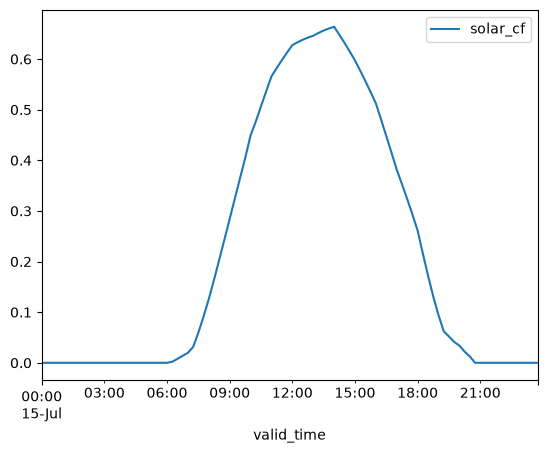

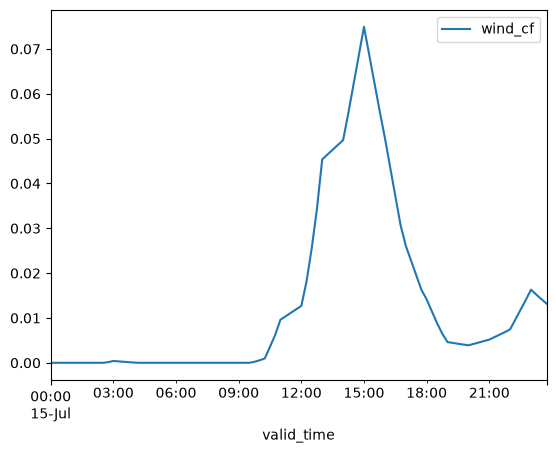

In [2]:
import matplotlib.pyplot as plt

print(solar_cf["solar_cf"].describe())
print(wind_cf["wind_cf"].describe())

solar_cf.loc["2020-07-15"].plot(label="solar")
wind_cf.loc["2020-07-15"].plot(label="wind")
plt.legend()
plt.show()

In [3]:
from scenarios.price_scenarios import (
    SCENARIOS,
    START_YEAR,
    END_YEAR,
    CONTRACT_START,
    CONTRACT_TERM_YEARS,
    load_price_trajectories,
    annual_price_trajectory,
    rescaled_price_trajectory,
    merit_order_adjustment_by_year,
    build_price_matrix,
)

CONTRACT_END = CONTRACT_START + CONTRACT_TERM_YEARS - 1

price_trajectories = load_price_trajectories()
price_trajectories

,2020,2025,2030,2035,2040,2045,2050
Scenario,,,,,,,
Delayed transition,66.906947,61.011068,54.073895,51.533594,52.983880,44.224782,35.266195
Nationally Determined Contributions (NDCs),66.906947,66.209143,66.003158,57.733173,44.777504,36.253353,35.300571
Net Zero 2050,66.906947,69.276722,71.597504,61.701835,44.519008,33.516271,33.017414


In [4]:
for scenario in SCENARIOS:
    modeled = annual_price_trajectory(scenario, 2026, 2041)
    rescaled = rescaled_price_trajectory(scenario, 2026, 2041)
    print(scenario)
    print(pd.DataFrame({"modeled": modeled, "rescaled": rescaled}))
    print()

Delayed transition
        modeled    rescaled
2026  59.623633  104.041346
2027  58.236198  101.620317
2028  56.848764   99.199288
2029  55.461329   96.778258
2030  54.073895   94.357229
2031  53.565835   93.470680
2032  53.057774   92.584131
2033  52.549714   91.697583
2034  52.041654   90.811034
2035  51.533594   89.924485
2036  51.823651   90.430625
2037  52.113708   90.936766
2038  52.403765   91.442906
2039  52.693823   91.949047
2040  52.983880   92.455187
2041  51.232060   89.398318



Nationally Determined Contributions (NDCs)
        modeled    rescaled
2026  66.167946  108.224352
2027  66.126749  108.156970
2028  66.085552  108.089589
2029  66.044355  108.022207
2030  66.003158  107.954825
2031  64.349161  105.249546
2032  62.695164  102.544267
2033  61.041167   99.838988
2034  59.387170   97.133709
2035  57.733173   94.428430
2036  55.142039   90.190369
2037  52.550905   85.952308
2038  49.959771   81.714247
2039  47.368638   77.476187
2040  44.777504   73.238126
2041  43.072674   70.449704

Net Zero 2050
        modeled    rescaled
2026  69.740878  109.999647
2027  70.205035  110.731744
2028  70.669191  111.463840
2029  71.133347  112.195936
2030  71.597504  112.928033
2031  69.618370  109.806420
2032  67.639236  106.684807
2033  65.660102  103.563194
2034  63.680968  100.441581
2035  61.701835   97.319968
2036  58.265269   91.899604
2037  54.828704   86.479239
2038  51.392138   81.058875
2039  47.955573   75.638510
2040  44.519008   70.218145
2041  42.318460   

In [5]:
merit_order_by_year = merit_order_adjustment_by_year()
pd.Series(merit_order_by_year).describe()

count    3.300000e+01
mean    -1.110223e-16
std      5.369561e-01
min     -1.050078e+00
25%     -2.837853e-01
50%      4.095488e-02
75%      4.286722e-01
max      8.781104e-01
dtype: float64

In [6]:
price_matrix = build_price_matrix()
price_matrix.shape

(15, 99)

In [7]:
layer_a = pd.DataFrame({
    ps: rescaled_price_trajectory(ps, CONTRACT_START, CONTRACT_END) for ps in SCENARIOS
})
recovered = price_matrix.T.groupby(level="price_scenario").mean().T[SCENARIOS]
print("max deviation from Layer A baseline:", (recovered - layer_a).abs().to_numpy().max())

for ps in SCENARIOS:
    year1 = price_matrix[ps].iloc[0]
    print(f"{ps:45s} {CONTRACT_START}: {year1.min():.2f}-{year1.max():.2f} €/MWh  (baseline {layer_a.loc[CONTRACT_START, ps]:.2f})")

max deviation from Layer A baseline: 1.4210854715202004e-14
Delayed transition                            2026: 102.99-104.92 €/MWh  (baseline 104.04)
Nationally Determined Contributions (NDCs)    2026: 107.17-109.10 €/MWh  (baseline 108.22)
Net Zero 2050                                 2026: 108.95-110.88 €/MWh  (baseline 110.00)
